# LSTM for Next-Month Affordability Percent Change

Uses one year of county-month history plus current-month `Affordability Metric`, `county_perc_mo`, `mortgage_rate`, `income`, and `avg_housing_price` to predict the next month percent change in `Affordability Metric`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
keras = tf.keras
layers = tf.keras.layers

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


## Load Data and Prepare Next-Month Percent-Change Target


In [2]:
# revised df has avg_housing_price included
df = pd.read_csv('../data/processed/final_3d_df_REVISED.csv')

df['date'] = pd.to_datetime({
    'year': df['year'].astype(int),
    'month': df['month'].astype(int),
    'day': 1
})

df = df.sort_values(['fips', 'date']).reset_index(drop=True)

grouped = df.groupby('fips', sort=False)

df['affordability_pct_change'] = grouped['Affordability Metric'].pct_change() * 100
df['next_affordability_metric'] = grouped['Affordability Metric'].shift(-1)
df['target_date'] = grouped['date'].shift(-1)

df['next_affordability_pct_change'] = (
    (df['next_affordability_metric'] / df['Affordability Metric']) - 1
) * 100

df[[
    'fips',
    'date',
    'target_date',
    'Affordability Metric',
    'avg_housing_price',
    'affordability_pct_change',
    'next_affordability_pct_change'
]].head()


,fips,date,target_date,Affordability Metric,avg_housing_price,affordability_pct_change,next_affordability_pct_change
0,1001,2006-12-01,2007-01-01,87.701976,163940.199861,NaN,4.334797
1,1001,2007-01-01,2007-02-01,91.503678,164297.125318,4.334797,4.786070
2,1001,2007-02-01,2007-03-01,95.883109,164967.775699,4.786070,1.519725
3,1001,2007-03-01,2007-04-01,97.340268,165492.145947,1.519725,11.409256
4,1001,2007-04-01,2007-05-01,108.446069,165851.129466,11.409256,-0.136739


## Build Current, Lag, and Rolling Features


In [3]:
target_column = 'next_affordability_pct_change'
current_features = [
    'Affordability Metric',
    'county_perc_mo',
    'mortgage_rate',
    'income',
    'avg_housing_price',
]
history_features = current_features + ['affordability_pct_change']

grouped = df.groupby('fips', sort=False)
for col in history_features:
    df[f'{col}_prev_mo'] = grouped[col].shift(1)
    df[f'{col}_rolling_3m'] = grouped[col].transform(
        lambda s: s.rolling(window=3, min_periods=1).mean()
    )
    df[f'{col}_rolling_12m'] = grouped[col].transform(
        lambda s: s.rolling(window=12, min_periods=1).mean()
    )

lag_rolling_features = [
    col for col in df.columns
    if col.endswith('_prev_mo') or col.endswith('_rolling_3m') or col.endswith('_rolling_12m')
]
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12).astype('float32')
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12).astype('float32')
feature_columns = current_features + lag_rolling_features + ['month_sin', 'month_cos']

model_df = df.dropna(subset=[target_column, 'target_date'] + feature_columns).reset_index(drop=True)

# Target sanity check: county_perc_mo is an input feature, not the label.
assert target_column == 'next_affordability_pct_change'
assert not np.allclose(
    model_df[target_column].values.astype('float32'),
    model_df['county_perc_mo'].values.astype('float32')
)

print(f'Target column: {target_column}')
print('county_perc_mo is used as a feature only:', 'county_perc_mo' in feature_columns)
print('county_perc_mo is target:', target_column == 'county_perc_mo')

model_df[[
    'fips', 'date', 'target_date', 'Affordability Metric', 'next_affordability_metric',
    'county_perc_mo', target_column
]].head(), model_df.shape, len(feature_columns), model_df[target_column].describe()

Target column: next_affordability_pct_change
county_perc_mo is used as a feature only: True
county_perc_mo is target: False


(   fips       date target_date  Affordability Metric  \
 0  1001 2007-02-01  2007-03-01             95.883109   
 1  1001 2007-03-01  2007-04-01             97.340268   
 2  1001 2007-04-01  2007-05-01            108.446069   
 3  1001 2007-05-01  2007-06-01            108.297781   
 4  1001 2007-06-01  2007-07-01            118.595218   
 
    next_affordability_metric  county_perc_mo  next_affordability_pct_change  
 0                  97.340268        0.312912                       1.519725  
 1                 108.446069        0.308228                      11.409256  
 2                 108.297781        0.276663                      -0.136739  
 3                 118.595218        0.277042                       9.508447  
 4                 136.271027        0.252987                      14.904318  ,
 (330327, 33),
 25,
 count    330327.000000
 mean          0.298213
 std          13.200854
 min         -96.271803
 25%          -2.929108
 50%          -0.067243
 75%           2.

In [4]:
split_year = 2020
# one year of history; tested better than the longer residual setup
lookback = 12

## LSTM Sequence Data

The sequence ends at the current county-month. The label is the next month percent change in `Affordability Metric`, so current-month affordability, income, mortgage rate, `county_perc_mo`, and housing price are valid inputs.

A current-month affordability percent-change baseline is kept only for comparison.


In [5]:
lstm_df = model_df.copy()

# FIPS is categorical. These integer codes are used only as embedding ids, not numeric features.
lstm_df['fips_code'] = pd.Categorical(lstm_df['fips'].astype(str)).codes.astype('int32')
n_fips = lstm_df['fips_code'].nunique()

target_year = lstm_df['target_date'].dt.year
row_train_mask = target_year <= 2019

lstm_x_scaler = StandardScaler()
lstm_y_scaler = StandardScaler()

scaled_features = np.empty((len(lstm_df), len(feature_columns)), dtype='float32')
scaled_features[row_train_mask.values] = lstm_x_scaler.fit_transform(
    lstm_df.loc[row_train_mask, feature_columns]
).astype('float32')
scaled_features[~row_train_mask.values] = lstm_x_scaler.transform(
    lstm_df.loc[~row_train_mask, feature_columns]
).astype('float32')

actual_y = lstm_df[target_column].values.reshape(-1, 1).astype('float32')
scaled_y = np.empty_like(actual_y, dtype='float32')
scaled_y[row_train_mask.values] = lstm_y_scaler.fit_transform(
    actual_y[row_train_mask.values]
).astype('float32')
scaled_y[~row_train_mask.values] = lstm_y_scaler.transform(
    actual_y[~row_train_mask.values]
).astype('float32')

baseline_column = 'affordability_pct_change'

X_sequences = []
X_sequence_fips = []
y_sequences = []
y_actual_sequences = []
y_baseline_sequences = []
sequence_row_indices = []

for _, county_df in lstm_df.groupby('fips', sort=False):
    indices = county_df.index.to_numpy()

    if len(indices) < lookback:
        continue

    for end_pos in range(lookback - 1, len(indices)):
        window_idx = indices[end_pos - lookback + 1:end_pos + 1]
        target_idx = indices[end_pos]

        X_sequences.append(scaled_features[window_idx])
        X_sequence_fips.append(lstm_df.at[target_idx, 'fips_code'])
        y_sequences.append(scaled_y[target_idx])
        y_actual_sequences.append(actual_y[target_idx])
        y_baseline_sequences.append(lstm_df.at[target_idx, baseline_column])
        sequence_row_indices.append(target_idx)

X_sequences = np.asarray(X_sequences, dtype='float32')
X_sequence_fips = np.asarray(X_sequence_fips, dtype='int32')
y_sequences = np.asarray(y_sequences, dtype='float32')
y_actual_sequences = np.asarray(y_actual_sequences, dtype='float32')
y_baseline_sequences = np.asarray(y_baseline_sequences, dtype='float32').reshape(-1, 1)

sequence_df = lstm_df.loc[sequence_row_indices].reset_index(drop=True)
sequence_target_year = sequence_df['target_date'].dt.year

sequence_train_mask = sequence_target_year <= 2019
sequence_val_mask = sequence_target_year == 2020
sequence_test_mask = sequence_target_year > 2020

X_lstm_train = X_sequences[sequence_train_mask]
X_lstm_val = X_sequences[sequence_val_mask]
X_lstm_test = X_sequences[sequence_test_mask]

X_lstm_train_fips = X_sequence_fips[sequence_train_mask]
X_lstm_val_fips = X_sequence_fips[sequence_val_mask]
X_lstm_test_fips = X_sequence_fips[sequence_test_mask]

y_lstm_train_scaled = y_sequences[sequence_train_mask]
y_lstm_val_scaled = y_sequences[sequence_val_mask]
y_lstm_test_scaled = y_sequences[sequence_test_mask]

y_lstm_train = y_actual_sequences[sequence_train_mask]
y_lstm_val = y_actual_sequences[sequence_val_mask]
y_lstm_test = y_actual_sequences[sequence_test_mask]

y_lstm_train_baseline = y_baseline_sequences[sequence_train_mask]
y_lstm_val_baseline = y_baseline_sequences[sequence_val_mask]
y_lstm_test_baseline = y_baseline_sequences[sequence_test_mask]

lstm_test_df = sequence_df.loc[sequence_test_mask].reset_index(drop=True)

print('Target-year split:')
print('Train target years:', sequence_target_year[sequence_train_mask].min(), '-', sequence_target_year[sequence_train_mask].max())
print('Validation target years:', sequence_target_year[sequence_val_mask].min(), '-', sequence_target_year[sequence_val_mask].max())
print('Test target years:', sequence_target_year[sequence_test_mask].min(), '-', sequence_target_year[sequence_test_mask].max())

print('\nShapes:')
print('X train:', X_lstm_train.shape)
print('X val:', X_lstm_val.shape)
print('X test:', X_lstm_test.shape)
print('y train:', y_lstm_train.shape)
print('y val:', y_lstm_val.shape)
print('y test:', y_lstm_test.shape)
print('n_fips:', n_fips)

print('\nTarget diagnostics:')
print('Actual train next-month pct-change std:', np.std(y_lstm_train))
print('Actual val next-month pct-change std:', np.std(y_lstm_val))
print('Actual test next-month pct-change std:', np.std(y_lstm_test))
print('Current-month-change baseline test R2:', r2_score(y_lstm_test, y_lstm_test_baseline))
print('Current-month-change baseline test MAE:', mean_absolute_error(y_lstm_test, y_lstm_test_baseline))


Target-year split:
Train target years: 2006 - 2019
Validation target years: 2020 - 2020
Test target years: 2021 - 2024

Shapes:
X train: (219221, 12, 25)
X val: (18718, 12, 25)
X test: (75117, 12, 25)
y train: (219221, 1)
y val: (18718, 1)
y test: (75117, 1)
n_fips: 1571

Target diagnostics:
Actual train next-month pct-change std: 14.375058
Actual val next-month pct-change std: 8.807722
Actual test next-month pct-change std: 10.158681
Current-month-change baseline test R2: -0.9002965688705444
Current-month-change baseline test MAE: 5.537497520446777


## LSTM Model

In [6]:
embedding_size = min(50, max(4, round(np.sqrt(n_fips))))

sequence_input = keras.Input(shape=(lookback, len(feature_columns)), name='numeric_sequence')
fips_input = keras.Input(shape=(), dtype='int32', name='fips_code')

# Direct next-month target model. The sequence ends at the current month; the label is next month
# affordability percent change, so current affordability and exogenous values are valid inputs.
x = layers.LSTM(64, return_sequences=True)(sequence_input)
x = layers.Dropout(0.20)(x)
x = layers.LSTM(32)(x)
x = layers.Dropout(0.15)(x)

fips_embedding = layers.Embedding(n_fips, embedding_size, name='fips_embedding')(fips_input)
fips_embedding = layers.Flatten()(fips_embedding)

x = layers.Concatenate()([x, fips_embedding])
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, name='scaled_pct_change_output')(x)

lstm_model = keras.Model(inputs=[sequence_input, fips_input], outputs=output)
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numeric_sequence    │ (None, 12, 25)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 12, 64)    │     23,040 │ numeric_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fips_code           │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fips_embedding      │ (None, 40)        │     62,840 │ fips_code[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 40)        │          0 │ fips_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,672 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_pct_change_… │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 105,081 (410.47 KB)

 Trainable params: 105,081 (410.47 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
lstm_history = lstm_model.fit(
    [X_lstm_train, X_lstm_train_fips], y_lstm_train_scaled,
    epochs=30,
    batch_size=1024,
    validation_data=([X_lstm_val, X_lstm_val_fips], y_lstm_val_scaled),
    verbose=1,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            min_delta=1e-4
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        )
    ]
)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - loss: 0.9466 - mae: 0.3558 - val_loss: 0.3232 - val_mae: 0.2669 - learning_rate: 0.0010
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.8235 - mae: 0.3511 - val_loss: 0.2941 - val_mae: 0.2546 - learning_rate: 0.0010
Epoch 3/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.7463 - mae: 0.3479 - val_loss: 0.2520 - val_mae: 0.2517 - learning_rate: 0.0010
Epoch 4/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.6584 - mae: 0.3453 - val_loss: 0.2337 - val_mae: 0.2534 - learning_rate: 0.0010
Epoch 5/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 0.6177 - mae: 0.3417 - val_loss: 0.2328 - val_mae: 0.2584 - learning_rate: 0.0010
Epoch 6/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.5669 - mae: 0.3384 - val_loss: 0.2433 - val_mae: 0.2722 - learning_rate: 0.0010
Epoch 7/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.4932 - mae: 0.3366 - val_loss: 0.2467 - val_mae: 0.2704 - learning_rate: 0.001

In [8]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


lstm_y_train_pred_scaled = lstm_model.predict([X_lstm_train, X_lstm_train_fips], verbose=0)
lstm_y_val_pred_scaled = lstm_model.predict([X_lstm_val, X_lstm_val_fips], verbose=0)
lstm_y_test_pred_scaled = lstm_model.predict([X_lstm_test, X_lstm_test_fips], verbose=0)

lstm_y_train_pred = lstm_y_scaler.inverse_transform(lstm_y_train_pred_scaled)
lstm_y_val_pred = lstm_y_scaler.inverse_transform(lstm_y_val_pred_scaled)
lstm_y_test_pred = lstm_y_scaler.inverse_transform(lstm_y_test_pred_scaled)

baseline_test_metrics = regression_metrics(y_lstm_test, y_lstm_test_baseline)

lstm_train_metrics = regression_metrics(y_lstm_train, lstm_y_train_pred)
lstm_val_metrics = regression_metrics(y_lstm_val, lstm_y_val_pred)
lstm_test_metrics = regression_metrics(y_lstm_test, lstm_y_test_pred)

print('Current-Month Change Baseline Test Set:')
for metric_name, value in baseline_test_metrics.items():
    print(f'{metric_name}: {value:.6f}')

for name, metrics in [
    ('Direct LSTM Train Set', lstm_train_metrics),
    ('Direct LSTM Validation Set', lstm_val_metrics),
    ('Direct LSTM Test Set', lstm_test_metrics)
]:
    print(f'\n{name}:')
    for metric_name, value in metrics.items():
        print(f'{metric_name}: {value:.6f}')

print('\nCollapse check:')
print(f'Actual test std:    {np.std(y_lstm_test):.6f}')
print(f'Baseline pred std:  {np.std(y_lstm_test_baseline):.6f}')
print(f'LSTM pred std:      {np.std(lstm_y_test_pred):.6f}')
print(f'Mean actual:        {np.mean(y_lstm_test):.6f}')
print(f'Mean prediction:    {np.mean(lstm_y_test_pred):.6f}')

lstm_test_r2 = lstm_test_metrics['R2']


Current-Month Change Baseline Test Set:
MSE: 196.108322
RMSE: 14.003868
MAE: 5.537498
R2: -0.900297

Direct LSTM Train Set:
MSE: 108.392975
RMSE: 10.411195
MAE: 4.805701
R2: 0.475456

Direct LSTM Validation Set:
MSE: 47.535480
RMSE: 6.894598
MAE: 3.692173
R2: 0.387240

Direct LSTM Test Set:
MSE: 83.733429
RMSE: 9.150597
MAE: 4.537804
R2: 0.188620

Collapse check:
Actual test std:    10.158681
Baseline pred std:  10.144478
LSTM pred std:      4.236203
Mean actual:        -0.634422
Mean prediction:    1.267688


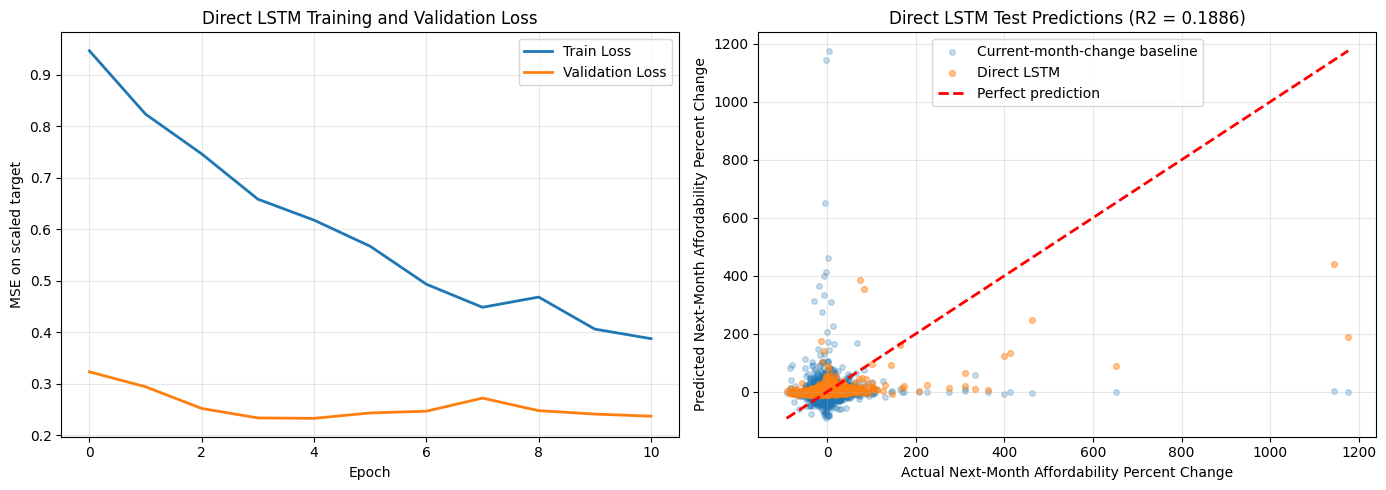

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE on scaled target')
axes[0].set_title('Direct LSTM Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_lstm_test, y_lstm_test_baseline, alpha=0.25, s=16, label='Current-month-change baseline')
axes[1].scatter(y_lstm_test, lstm_y_test_pred, alpha=0.45, s=18, label='Direct LSTM')
min_val = min(y_lstm_test.min(), lstm_y_test_pred.min(), y_lstm_test_baseline.min())
max_val = max(y_lstm_test.max(), lstm_y_test_pred.max(), y_lstm_test_baseline.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Next-Month Affordability Percent Change')
axes[1].set_ylabel('Predicted Next-Month Affordability Percent Change')
axes[1].set_title(f'Direct LSTM Test Predictions (R2 = {lstm_test_metrics["R2"]:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


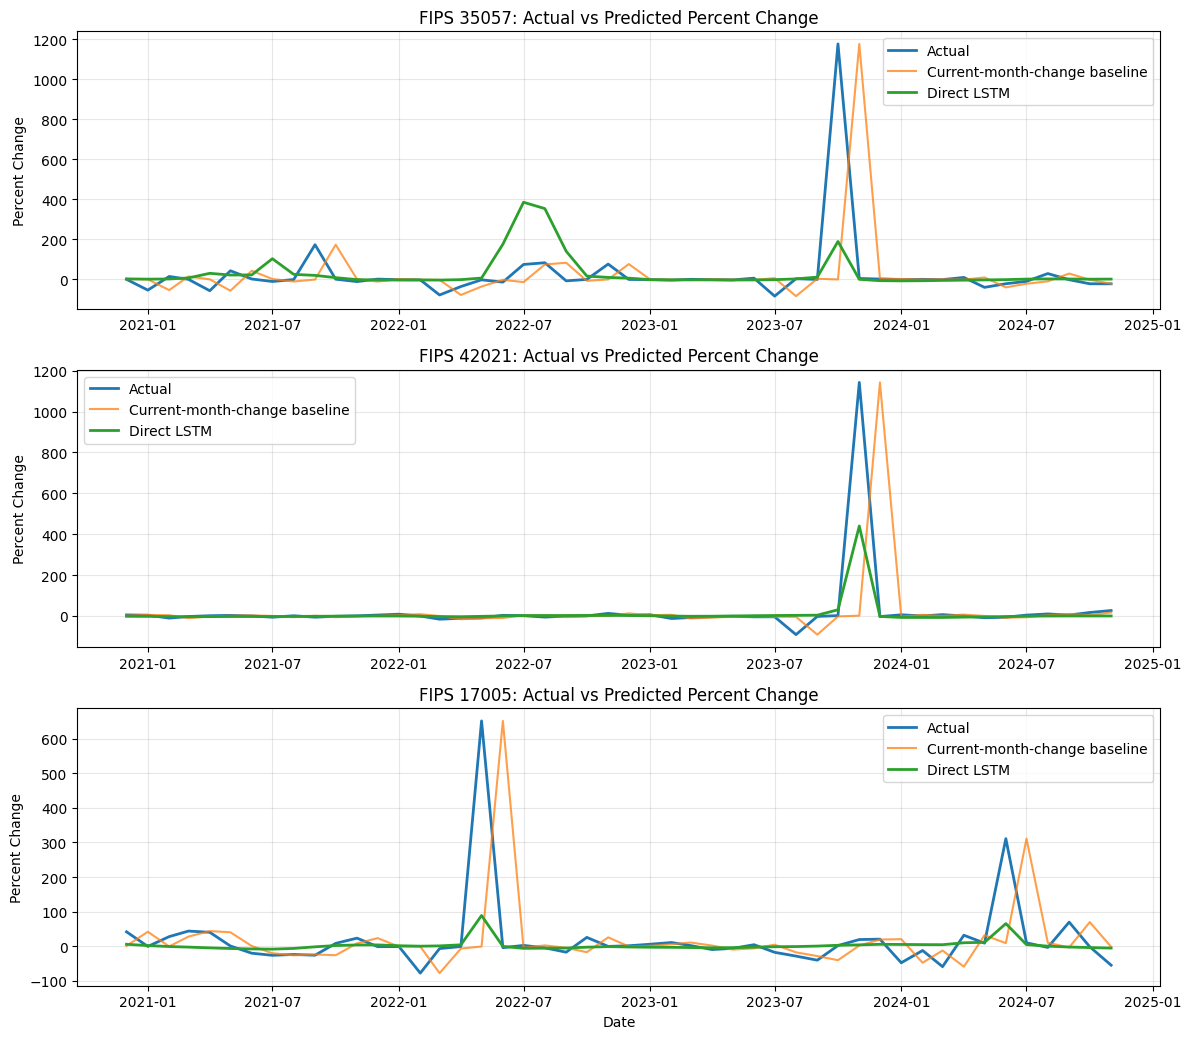

In [10]:
lstm_plot_df = lstm_test_df.copy()
lstm_plot_df['actual'] = y_lstm_test.reshape(-1)
lstm_plot_df['baseline'] = y_lstm_test_baseline.reshape(-1)
lstm_plot_df['predicted'] = lstm_y_test_pred.reshape(-1)

# Pick counties with high movement so the plot tests whether the model learned changes.
county_movement = lstm_plot_df.groupby('fips')['actual'].std().sort_values(ascending=False)
top_fips = county_movement.head(3).index.tolist()

fig, axes = plt.subplots(len(top_fips), 1, figsize=(12, 3.5 * len(top_fips)), sharex=False)
if len(top_fips) == 1:
    axes = [axes]

for ax, fips in zip(axes, top_fips):
    county = lstm_plot_df[lstm_plot_df['fips'] == fips].sort_values('date')
    ax.plot(county['date'], county['actual'], label='Actual', linewidth=2)
    ax.plot(county['date'], county['baseline'], label='Current-month-change baseline', linewidth=1.5, alpha=0.75)
    ax.plot(county['date'], county['predicted'], label='Direct LSTM', linewidth=2)
    ax.set_title(f'FIPS {fips}: Actual vs Predicted Percent Change')
    ax.set_ylabel('Percent Change')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


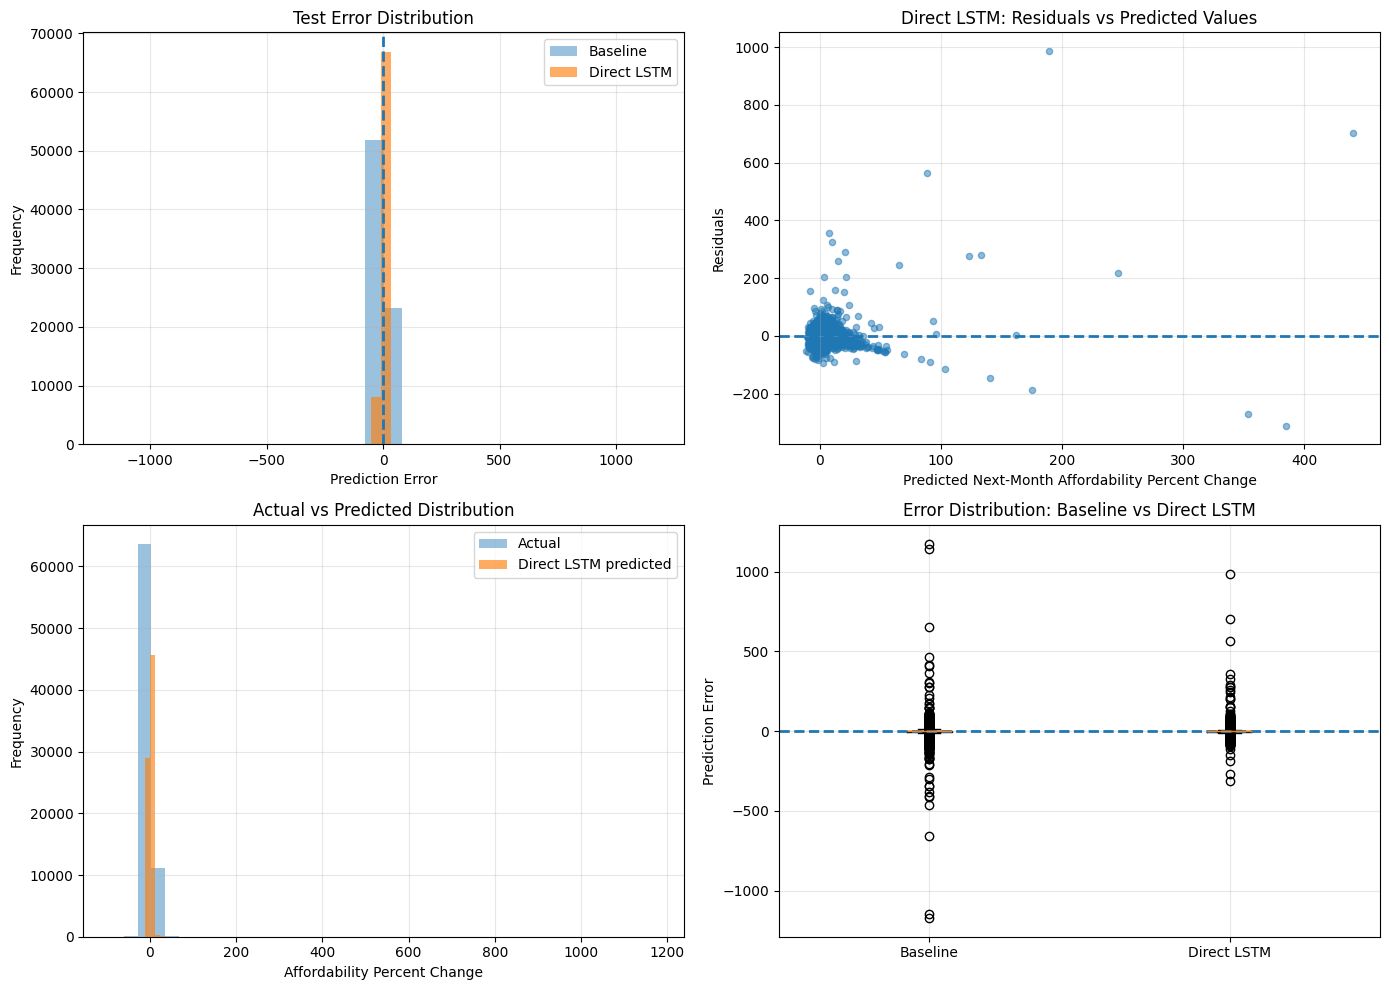

Direct LSTM Error Statistics:
Mean Error: -1.902110
Std Error: 8.950721
Min Error: -310.691528
Max Error: 986.299194
Prediction Std / Actual Std: 0.417


In [11]:
# Additional analysis: error distribution and anti-collapse diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

lstm_residuals = y_lstm_test.flatten() - lstm_y_test_pred.flatten()
baseline_residuals = y_lstm_test.flatten() - y_lstm_test_baseline.flatten()

axes[0, 0].hist(baseline_residuals, bins=30, alpha=0.45, label='Baseline')
axes[0, 0].hist(lstm_residuals, bins=30, alpha=0.65, label='Direct LSTM')
axes[0, 0].set_xlabel('Prediction Error')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Test Error Distribution')
axes[0, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(lstm_y_test_pred, lstm_residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Next-Month Affordability Percent Change')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Direct LSTM: Residuals vs Predicted Values')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(y_lstm_test.flatten(), bins=40, alpha=0.45, label='Actual')
axes[1, 0].hist(lstm_y_test_pred.flatten(), bins=40, alpha=0.65, label='Direct LSTM predicted')
axes[1, 0].set_xlabel('Affordability Percent Change')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Actual vs Predicted Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot([baseline_residuals, lstm_residuals], tick_labels=['Baseline', 'Direct LSTM'])
axes[1, 1].set_ylabel('Prediction Error')
axes[1, 1].set_title('Error Distribution: Baseline vs Direct LSTM')
axes[1, 1].axhline(y=0, linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Direct LSTM Error Statistics:')
print(f'Mean Error: {np.mean(lstm_residuals):.6f}')
print(f'Std Error: {np.std(lstm_residuals):.6f}')
print(f'Min Error: {np.min(lstm_residuals):.6f}')
print(f'Max Error: {np.max(lstm_residuals):.6f}')
print(f'Prediction Std / Actual Std: {np.std(lstm_y_test_pred) / (np.std(y_lstm_test) + 1e-6):.3f}')
